# Experiment 12: SHAP Explainability

This experiment uses SHAP values to explain model predictions and understand how individual features contribute to machine failure risk.

Unlike feature importance, SHAP provides both global and local explanations for model behavior.

In [1]:
# ===================================================
# Imports
# ===================================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import shap

from src.data.load_data import (
    load_ai4i_dataset
)

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.champion_model import (
    build_champion_xgboost_model
)

from src.explainability.shap_analysis import (
    create_shap_explainer,
    calculate_shap_values
)

from sklearn.model_selection import (
    train_test_split
)


# ===================================================
# Pipeline
# ===================================================

df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


# ===================================================
# Train Champion Model
# ===================================================

model = build_champion_xgboost_model()

model.fit(
    X_train,
    y_train
)


# ===================================================
# SHAP
# ===================================================

explainer = create_shap_explainer(
    model
)

shap_values = calculate_shap_values(
    explainer,
    X_test
)

print(
    shap_values.shape
)

(2000, 12)


## SHAP Global Feature Analysis

This visualization shows the overall impact of each feature on model predictions across the test dataset.

Features are ranked by their average contribution to machine failure risk.

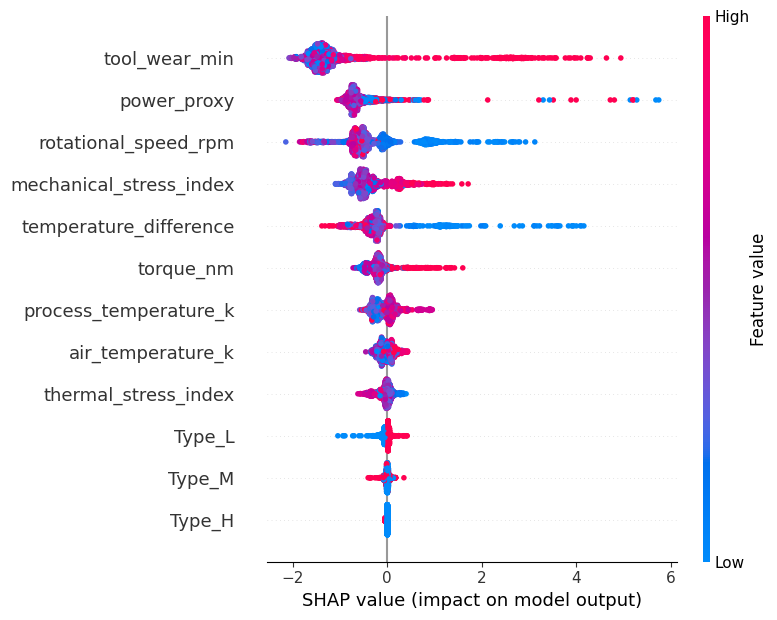

In [2]:
shap.summary_plot(
    shap_values,
    X_test
)

Experiment 12 Findings

The SHAP analysis revealed that tool wear, power proxy, rotational speed, and mechanical stress index were among the most influential drivers of model predictions.

Higher tool wear, power consumption, torque, and mechanical stress generally increased failure risk, while lower rotational speeds were associated with higher probabilities of machine failure.

Product type features contributed relatively little to model decisions, indicating that the model primarily relies on operational sensor measurements and engineered features.

## Local Prediction Explanation

In [3]:
failed_indices = y_test[y_test == 1].index

sample_index = failed_indices[0]

sample_position = X_test.index.get_loc(sample_index)

print("Sample Index:", sample_index)

Sample Index: 4851


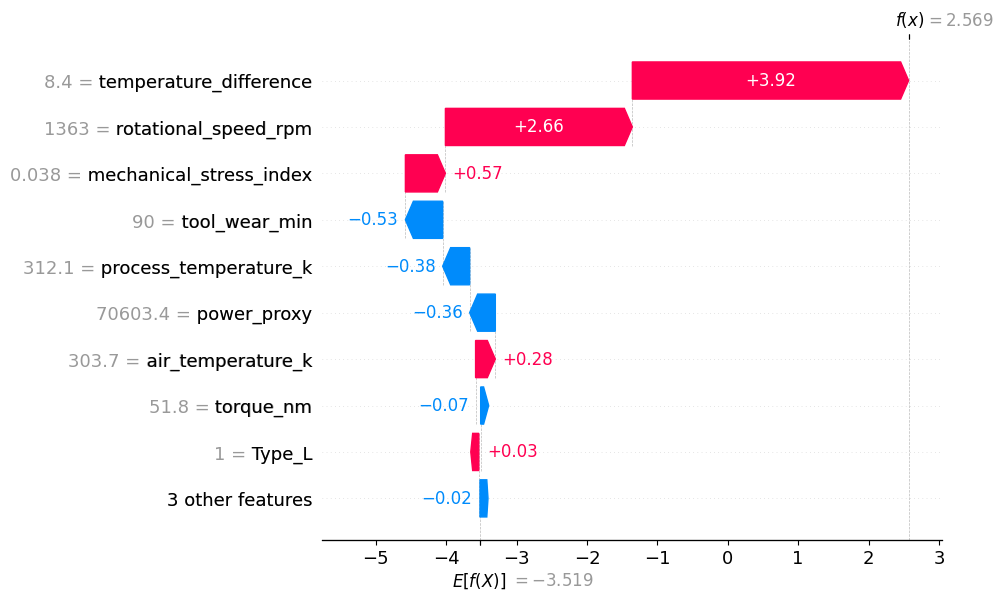

In [4]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_position],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_position],
        feature_names=X_test.columns
    )
)

Experiment 12 Findings

SHAP local explanations showed how individual features influenced predictions for specific machines.

For the selected failure case, temperature difference and low rotational speed were the strongest contributors to predicted failure risk, while tool wear and process temperature reduced the overall risk score.

These local explanations demonstrate that the model can provide interpretable reasoning for individual predictions rather than functioning as a black-box classifier.